# MÓDULO 35 - Cross Validation
## Previsão de Intenção de Compra de Clientes em Loja Web

### Contexto

A previsão da intenção de compra em sites de e-commerce é um recurso estratégico para aprimorar a experiência do cliente e direcionar de forma eficaz as ações de marketing da empresa. A análise de dados históricos de clientes, incluindo informações demográficas, renda, estado civil e comportamento de compra, pode revelar padrões importantes que indicam maior probabilidade de realizar compras online.

### 🎯 Objetivo Geral

Desenvolver um modelo preditivo para analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa.

### Objetivos Complementares

* **Pré-processamento pt-1:** Tratar variáveis não úteis, inconsistentes e preparar os dados para modelagem.  
* **Modelagem:** Implementar modelos de classificação supervisionada para prever a intenção de compra dos clientes.  
* **Avaliação:** Medir métricas de performance (acurácia, precisão, recall, F1-score) para verificar a robustez do modelo.  

### 🗄️ Base de Dados

A base de dados contém informações demográficas e de comportamento de consumo dos clientes, conforme a **Tabela 1**.

| Feature             | Descrição                                                      |
| ------------------- | -------------------------------------------------------------- |
| Year_Birth          | Ano de nascimento do cliente                                   |
| Education           | Nível de escolaridade do cliente                               |
| Marital_Status      | Estado civil do cliente                                        |
| Income              | Renda anual da família do cliente                              |
| Kidhome             | Número de crianças na casa do cliente                          |
| Recency             | Número de dias desde a última compra do cliente                |
| Complain            | 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário   |
| MntWines            | Valor gasto em vinhos nos últimos 2 anos                       |
| MntFruits           | Valor gasto em frutas nos últimos 2 anos                       |
| MntMeatProducts     | Valor gasto em carnes nos últimos 2 anos                       |
| MntFishProducts     | Valor gasto em peixes nos últimos 2 anos                       |
| MntSweetProducts    | Valor gasto em doces nos últimos 2 anos                        |
| MntGoldProds        | Valor gasto em produtos de ouro nos últimos 2 anos             |
| NumStorePurchases   | Número de compras feitas diretamente nas lojas                 |
| NumWebVisitsMonth   | Número de visitas ao site da empresa no último mês             |
| **WebPurchases**    | compra no website. 0 não, 1 sim.                 |

**Tabela 1**: Variáveis do dataframe


# ETAPA 1: Preparação dos Dados

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

## Aquisição e Preparação de Dados
- Importar bibliotecas.  
- Carregar dados (CSV, Excel, SQL, API).  
- Verificar dimensões e primeiras linhas (`df.shape`, `df.head()`). 

### 1.1 Data Load (Carregamento) 

In [1]:
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.base import clone


# Configuração de warnings
warnings.filterwarnings("ignore", category=FutureWarning)
dfo = pd.read_csv('/home/akel/PycharmProjects/EBAC/dados/marketing_campaign.csv', delimiter=';')

dfo.head(5)

,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1


### 1.2 Pré-Processamento Inicial
- Exploração bruta (`df.info()`, `df.describe()`).  
- Tratamento de **valores faltantes** (remover ou imputar).  
- Remoção de **duplicados**.  


In [2]:
print("=" * 50)
print("ANÁLISE EXPLORATÓRIA DO DATAFRAME")
print("=" * 50)
# Informações sobre o shape dos dados
print(f"\n📊 DIMENSÕES: {dfo.shape[0]} linhas × {dfo.shape[1]} colunas")
df = dfo.copy()

# Informações sobre tipos de dados
print(f"\n🔧 TIPOS DE DADOS:")
print(df.dtypes.to_frame('Tipo').to_markdown())

# Contagem de duplicatas
print("=" * 50)
print("🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos")
print(f"Total registros duplicados: {df.duplicated().sum()}")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")

print("=" * 50)
# Remoção duplicadas
df = df.drop_duplicates()
# remoção de nulos
if df.isnull().sum().sum()/(dfo.shape[0])*100 > 5:
    print('‼️ Avaliar critérios de exclusão')
else:
    df = df.dropna()
print("🧹 REMOÇÃO DE DUPLICATAS & Nulos")
print(f"Total de valores nulos: {df.isnull().sum().sum()}")
print(f"Total registros duplicados: {df.duplicated().sum()}")
print(f"📊 Novas DIMENSÕES: {df.shape[0]} linhas × {df.shape[1]} colunas")


ANÁLISE EXPLORATÓRIA DO DATAFRAME

📊 DIMENSÕES: 2240 linhas × 16 colunas

🔧 TIPOS DE DADOS:
|                   | Tipo    |
|:------------------|:--------|
| Year_Birth        | int64   |
| Education         | object  |
| Marital_Status    | object  |
| Income            | float64 |
| Kidhome           | int64   |
| Recency           | int64   |
| MntWines          | int64   |
| MntFruits         | int64   |
| MntMeatProducts   | int64   |
| MntFishProducts   | int64   |
| MntSweetProducts  | int64   |
| MntGoldProds      | int64   |
| NumStorePurchases | int64   |
| NumWebVisitsMonth | int64   |
| Complain          | int64   |
| WebPurchases      | int64   |
🔍 VERIFICAÇÃO DE DUPLICATAS & Nulos
Total registros duplicados: 201
Total de valores nulos: 24
🧹 REMOÇÃO DE DUPLICATAS & Nulos
Total de valores nulos: 0
Total registros duplicados: 0
📊 Novas DIMENSÕES: 2015 linhas × 16 colunas


### 1.3 Limpeza e Consistência
- Padronização de categorias.  
- Tratamento de valores inválidos.  

In [3]:
# Padronização de categorias
df["Marital_Status"] = df["Marital_Status"].replace({
     "Single": "Single",
     "Alone": "Single",
     "YOLO": "Other",
     "Absurd": "Other",
    "Together": "Married",
     "Married": "Married",
     "Divorced": "Divorced",
     "Widow": "Widow"})

# Consistencia de valores 
# 1915 < anos de nascimento < 2015
df = df[(df["Year_Birth"] >= 1915) & (df["Year_Birth"] <= 2015)]
# renda deve ser positiva >0
df = df[df["Income"] > 0]        

print("=" * 50)
print("RESUMO")
print("=" * 50)
# Padronização de categorias
print("CATEGORIAS:")
for col in ["Education", "Marital_Status"]:
    if col in df.columns:
        print(f"{str.upper(col)}: {df[col].unique()}")
print(f"📊 Novas DIMENSÕES: {df.shape[0]} linhas × {df.shape[1]} colunas")

RESUMO
CATEGORIAS:
EDUCATION: ['Graduation' 'PhD' 'Master' 'Basic' '2n Cycle']
MARITAL_STATUS: ['Single' 'Married' 'Divorced' 'Widow' 'Other']
📊 Novas DIMENSÕES: 2012 linhas × 16 colunas


---

# ETAPA 2: Pré-processamento

## Análise Exploratória e Engenharia de Variáveis
- Distribuição de variáveis.
- Identificação e remoção outliers  
- Relação entre variáveis.  
- Correlações e heatmap.
### 2.1 EDA (Exploratory Data Analysis)

In [4]:
def mult_plt(df,kind='hist', ncols=3, max_bins=15, figsize=(16, 24),min_boxplot=6,suptitle=None):

    """
    Gera automaticamente visualizações (histogramas ou boxplots)
    para todas as colunas numéricas de um DataFrame.

    Parâmetros
    ----------
    df : pd.DataFrame
        DataFrame contendo as colunas numéricas para visualização.
    kind : str, padrão="hist"
        Tipo de visualização: "hist" para histograma ou "box" para boxplot.
    ncols : int, padrão=3
        Número de colunas no grid de subplots.
    max_bins : int, padrão=15
        Máximo de bins para histogramas.
    figsize : Tuple[int, int], padrão=(16, 24)
        Tamanho da figura.
    suptitle : str, opcional
        Título geral da figura.
    min_unique_values_for_boxplot : int, padrão=6
        Número mínimo de valores únicos para incluir a variável em boxplot.

    Retorno
    -------
    None
        Exibe os gráficos diretamente.
    """

    def nice_bin_width(data_range: float, max_bins: int) -> float:
        """Calcula largura de bin 'redonda' para histogramas."""
        raw_dx = data_range / max_bins
        nice_steps = [1, 2, 2.5, 5, 10]
        scale = 10 ** math.floor(math.log10(raw_dx))
        for step in nice_steps:
            candidate = step * scale
            n_bins = math.ceil(data_range / candidate)
            if n_bins <= max_bins:
                return candidate
        return data_range / max_bins

    cols = df.select_dtypes(include=[np.number]).columns.tolist()

    # FILTRAR COLUNAS para boxplot
    if kind == "box":
        cols = [col for col in cols if df[col].nunique() >= min_boxplot]

    nrows = math.ceil(len(cols) / ncols)

    fig, ax = plt.subplots(nrows, ncols, figsize=figsize)
    ax = np.array(ax).reshape(nrows, ncols)

    if not suptitle:
        suptitle = "Histogramas" if kind == "hist" else "Boxplots"
    fig.suptitle(suptitle, fontsize=18, y=1.007)

    for idx, col in enumerate(cols):
        row, col_idx = divmod(idx, ncols)
        temp = df[col].dropna()

        if kind == "hist":
            unique_vals = np.sort(temp.unique())
            if np.issubdtype(temp.dtype, np.integer) and len(unique_vals) <= 8:
                dx = 1
                align = 'center'
                bins = np.arange(min(unique_vals), max(unique_vals) + dx + 1, dx)
            else:
                data_range = temp.max() - temp.min()
                dx = nice_bin_width(data_range, max_bins)
                align = 'edge'
                bins = np.arange(temp.min(), temp.max() + dx, dx)

            counts, edges = np.histogram(temp, bins)
            perc = counts / len(temp) * 100

            ax[row, col_idx].bar(
                edges[:-1], perc, width=np.diff(bins), align=align,
                color='dodgerblue', edgecolor='black'
            )
            ax[row, col_idx].set_title(col)
            ax[row, col_idx].set_xlabel(col)
            ax[row, col_idx].set_ylabel('Percentual (%)')
            ax[row, col_idx].set_xticks(bins[:-1])
            if len(bins) >= 10:
                ax[row, col_idx].set_xticklabels(bins[:-1], rotation=45)

            for i in range(len(counts)):
                fs = max(6, 10 - len(counts) // 5)
                if align == 'center':
                    bar_center = bins[i]
                else:
                    bar_center = bins[i] + (bins[i + 1] - bins[i]) / 2
                ax[row, col_idx].text(
                    bar_center, perc[i], f'{perc[i]:.1f}%',
                    ha='center', va='bottom', fontsize=fs
                )

        elif kind == "box":
            sns.boxplot(x=temp, color="tomato", ax=ax[row, col_idx])
            ax[row, col_idx].set_title(col)
            ax[row, col_idx].set_xlabel(col)
            ax[row, col_idx].set_ylabel("")

    # Remove subplots extras
    for j in range(len(cols), nrows * ncols):
        row, col_idx = divmod(j, ncols)
        ax[row, col_idx].set_visible(False)

    plt.tight_layout()
    plt.show()
    
#mult_plt(df)

print(f"\n📈 ESTATÍSTICAS NUMÉRICAS:")
display(df.select_dtypes(include=['number']).describe())
#mult_plt(df,kind='box',ncols=4,figsize=(16, 12))  



📈 ESTATÍSTICAS NUMÉRICAS:


,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000,2012.000000
mean,1968.890159,52350.451789,0.442346,48.984592,304.663519,26.375746,167.779821,37.576541,27.186879,43.635189,5.788767,5.316103,0.009443,0.506461
std,11.670785,25587.311949,0.536260,28.951961,336.595649,39.783476,226.337621,54.853538,41.495009,51.506003,3.236511,2.436969,0.096741,0.500083
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35502.500000,0.000000,24.000000,23.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51533.000000,0.000000,49.000000,176.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68634.000000,1.000000,74.000000,505.000000,33.000000,230.000000,50.000000,34.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


### 2.2 Remoção de outliers

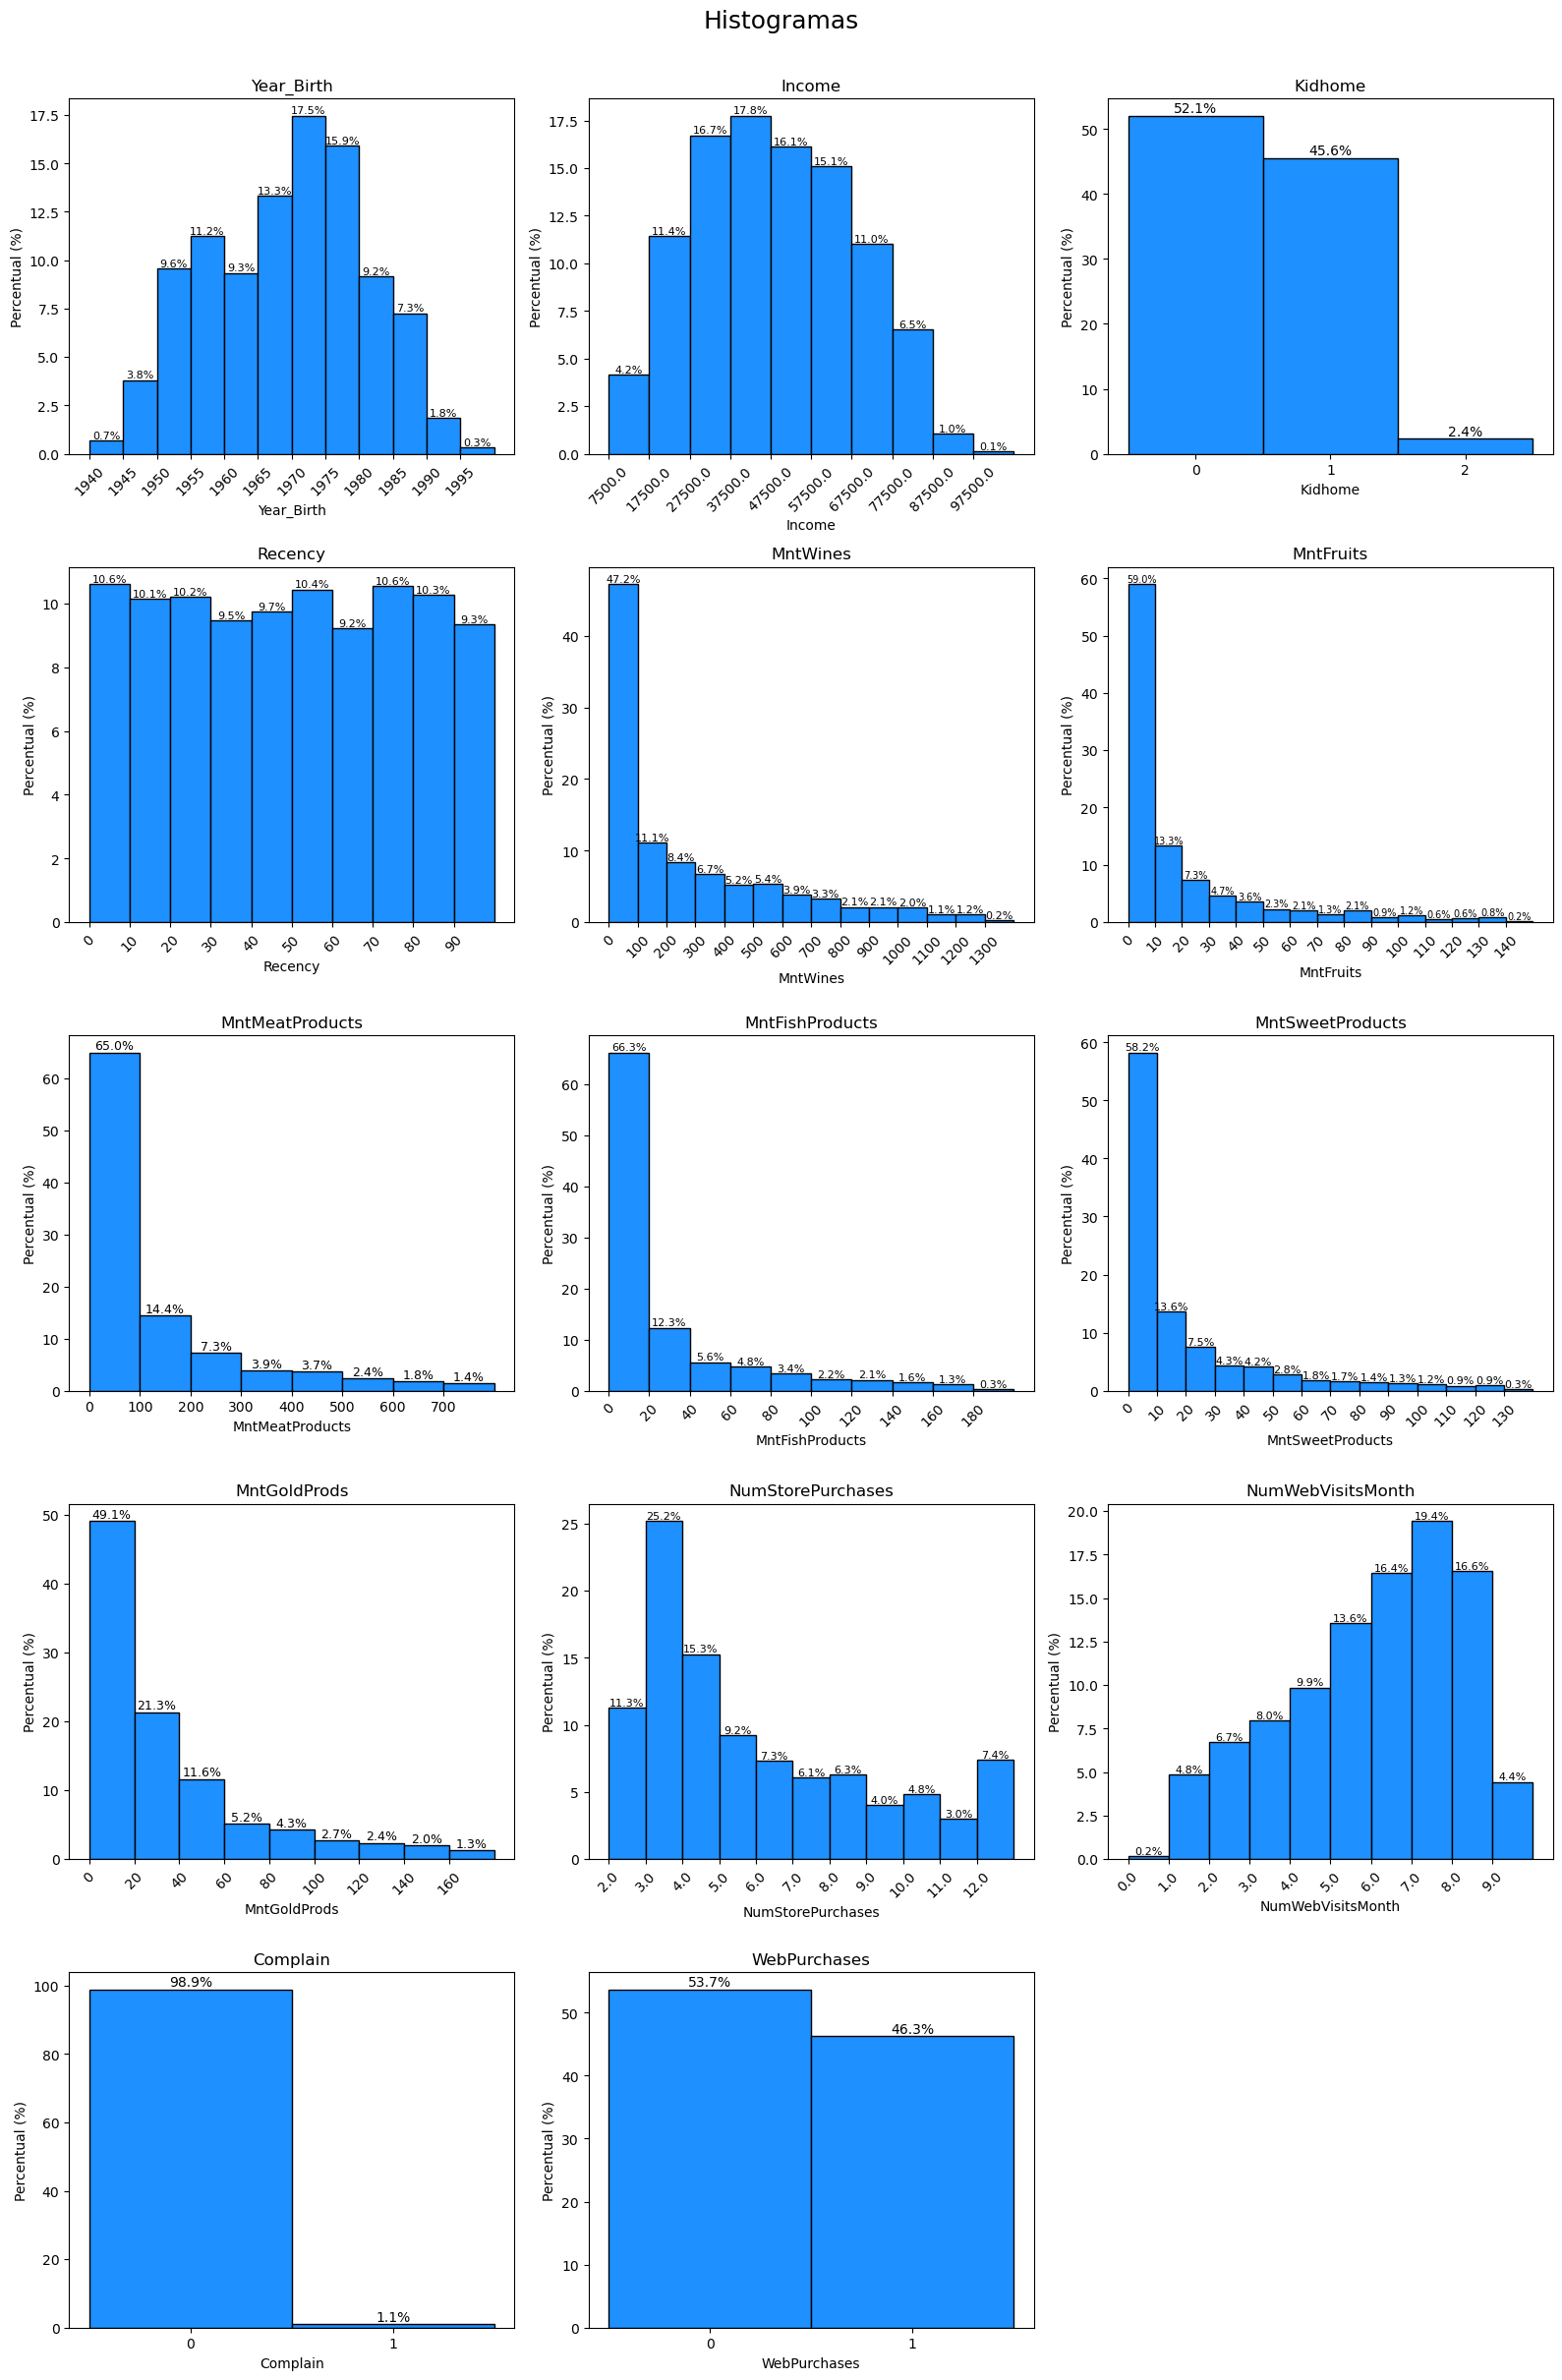

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000
mean,1968.877163,48536.734717,0.502884,48.955594,265.376586,18.504614,122.673587,26.482122,18.550173,34.267013,5.521915,5.566321,0.010957,0.463091
std,11.561193,19155.938677,0.545392,28.913740,317.137232,28.171037,168.295733,39.288559,27.689119,38.341011,3.138528,2.163789,0.104132,0.498780
min,1940.000000,7500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,1959.000000,33623.750000,0.000000,24.000000,19.000000,1.000000,14.000000,2.000000,1.000000,7.000000,3.000000,4.000000,0.000000,0.000000
50%,1970.000000,47412.500000,0.000000,49.000000,128.500000,6.000000,48.000000,10.000000,6.000000,20.000000,4.000000,6.000000,0.000000,0.000000
75%,1977.000000,63275.250000,1.000000,74.000000,427.500000,23.000000,154.000000,33.000000,23.000000,45.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,101970.000000,2.000000,99.000000,1315.000000,142.000000,792.000000,185.000000,134.000000,178.000000,13.000000,10.000000,1.000000,1.000000


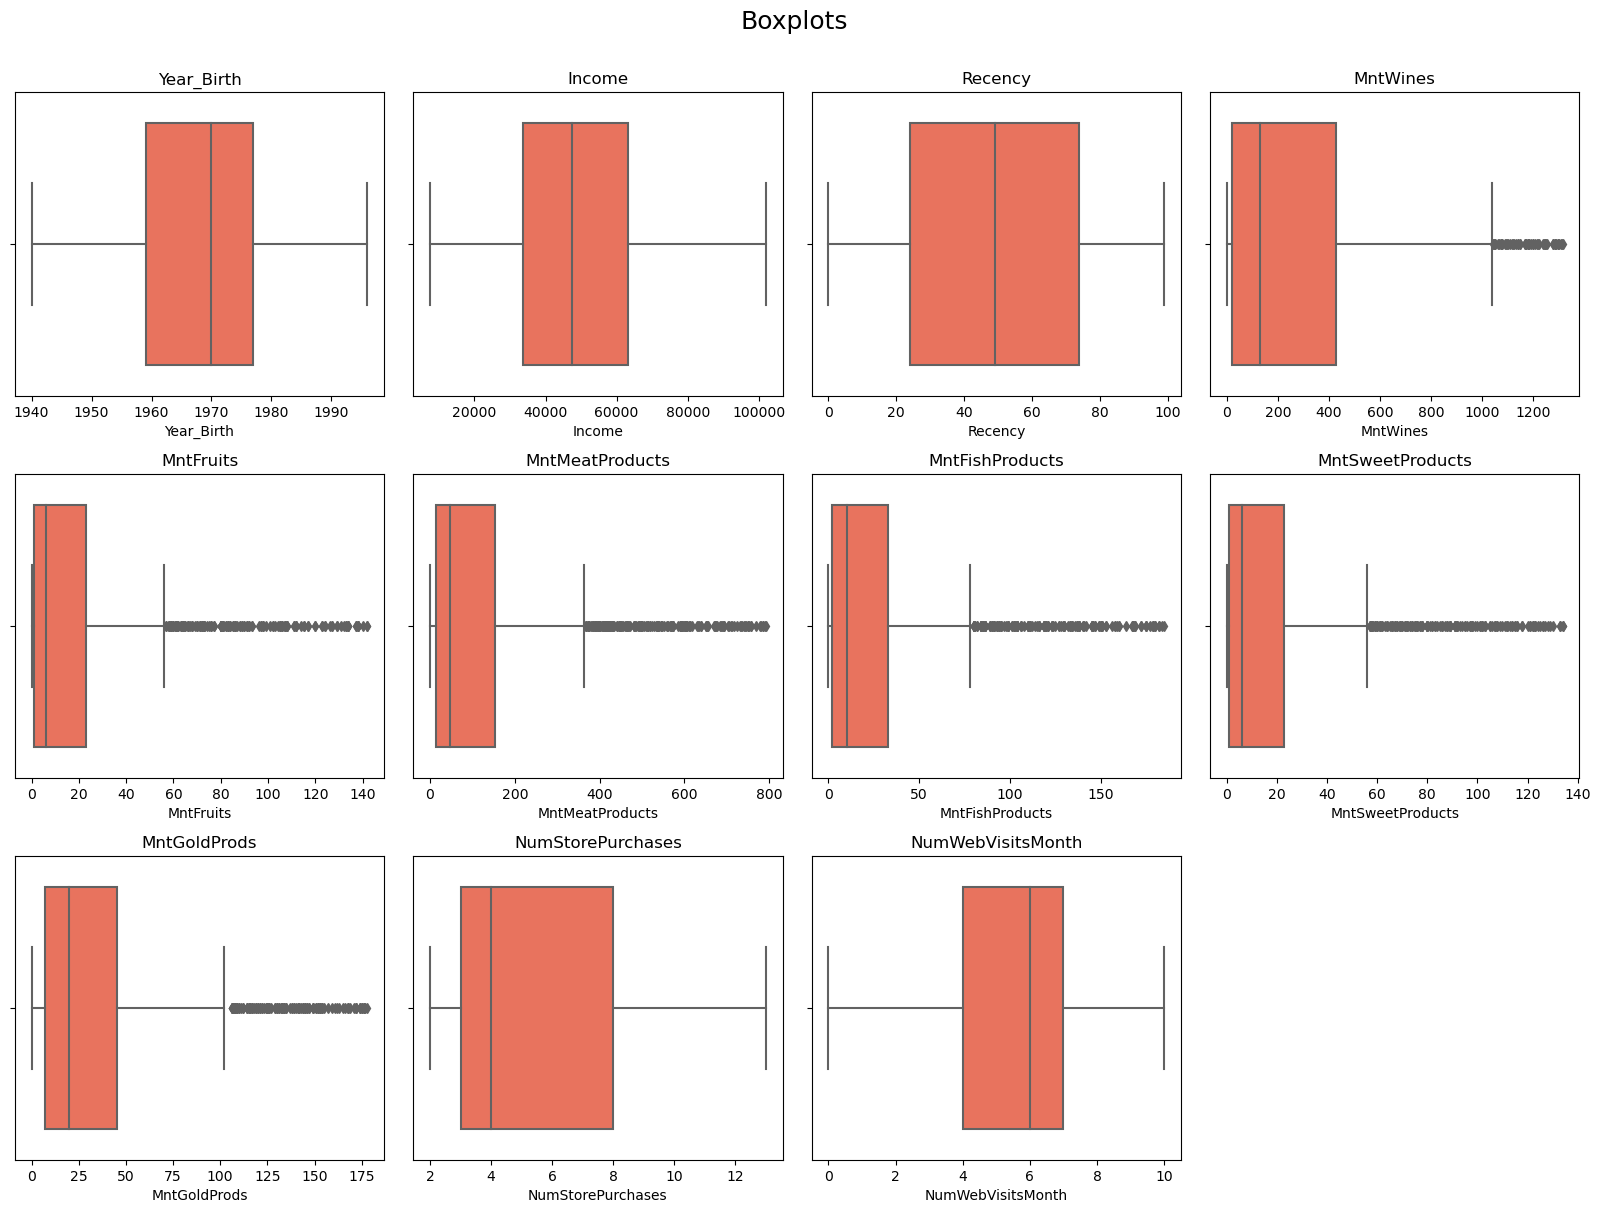

In [5]:
def remove_outliers_zscore(data, cols, threshold=3):
    df_clean = data.copy()
    for col in cols:
        mean = df_clean[col].mean()
        std = df_clean[col].std()
        
        # Calcula z-score
        z_scores = (df_clean[col] - mean) / std
        
        # Mantém apenas valores dentro do limite
        df_clean = df_clean[np.abs(z_scores) <= threshold]
    return df_clean

# Aplicar
num_cols = df.select_dtypes(include=['number']).columns

cols_criticas = ["Income","MntWines", "MntFruits",  "MntMeatProducts","MntFishProducts",
                 "MntSweetProducts",
                 "MntGoldProds",'NumWebVisitsMonth']

df2 = remove_outliers_zscore(df,cols_criticas)

#plotagem
mult_plt(df2)
display(df2.select_dtypes(include=['number']).describe())
mult_plt(df2,kind='box',ncols=4,figsize=(16, 12))  

#### 📊 Resumo estatístico após remoção de outliers (Z-score, t=3)

Nesta etapa do processamento de dados foi realizada a remoção de outliers utilizando o método do Z-score com um limiar (threshold) igual a 3. O objetivo foi eliminar observações que apresentavam valores extremos em relação à média das variáveis, reduzindo o impacto dessas discrepâncias nas análises posteriores. Esse procedimento resultou em uma redução de aproximadamente 13,8% no volume total de dados (de 2012 para 1734 registros), afetando principalmente variáveis relacionadas a consumo e renda. Após a limpeza, observou-se uma redução significativa na média, mediana e desvio padrão de várias variáveis, especialmente aquelas com grande dispersão, como Income, MntWines, MntMeatProducts e MntSweetProducts. O processo tornou os dados mais homogêneos, preservando a estrutura geral do conjunto, mas eliminando distorções causadas por casos extremos, melhorando assim a qualidade das análises subsequentes

* **Geral :** Após remoção de outliers pelo Z-score (t=3), o número de registros caiu de 2012 → 1734, uma redução de ~13,8%. A limpeza afetou principalmente variáveis de consumo e renda.

* **Year_Birth :** Não sofreu alteração relevante (média ~1969, mediana 1970, desvio ~11,6). Idades não tinham outliers extremos.

* **Income :** Média caiu de 52,350 → 48,537, mediana de 51,533 → 47,413, desvio reduziu de 25,587 → 19,156. Remoção de rendas extremamente altas (até 666,666 antes → 101,970 depois).

* **Kidhome :** Média aumentou ligeiramente de 0,442 → 0,503, mediana manteve-se em 0, desvio praticamente igual (~0,545). Pouca influência de outliers.

* **Recency :** Média e mediana praticamente estáveis (~49), desvio quase igual (~28,9). Não havia outliers relevantes.

* **MntWines :** Média caiu de 304,664 → 265,377, mediana de 176,0 → 128,5, desvio reduziu de 336,596 → 317,137. Clientes com compras exageradas de vinho foram filtrados.

* **MntFruits :** Média caiu de 26,376 → 18,505, mediana de 8,0 → 6,0, desvio reduziu de 39,783 → 28,171. Forte redução da dispersão.

* **MntMeatProducts :** Média caiu de 167,780 → 122,674, mediana de 68,0 → 48,0, desvio reduziu de 226,338 → 168,296. Grande impacto dos outliers removidos.

* **MntFishProducts :** Média caiu de 37,577 → 26,482, mediana de 12,0 → 10,0, desvio reduziu de 54,854 → 39,289. Menos clientes com gastos muito acima da média.

* **MntSweetProducts :** Média caiu de 27,187 → 18,550, mediana de 8,0 → 6,0, desvio reduziu de 41,495 → 27,689. Consumo mais homogêneo.

* **MntGoldProds :** Média caiu de 43,635 → 34,267, mediana de 24,0 → 20,0, desvio reduziu de 51,506 → 38,341. Redução da dispersão, corte de grandes compradores.

* **NumStorePurchases :** Média caiu de 5,789 → 5,522, mediana de 5,0 → 4,0, desvio praticamente igual (~3,14). Impacto limitado.

* **NumWebVisitsMonth :** Média quase estável (5,316 → 5,566), mediana igual (6,0), pequeno ajuste no desvio (2,437 → 2,164). Só os extremos foram cortados.

* **Complain :** Média caiu de 0,009 → 0,011, mediana igual (0,0), pequeno ajuste no desvio (0,097 → 0,104). Alguns casos foram removidos, mas não todos.

* **WebPurchases :** Média caiu de 0,506 → 0,463, mediana de 1,0 → 0,0, desvio estável (~0,50). Os outliers estavam entre clientes que compravam muito online.

### 2.3 Correlação

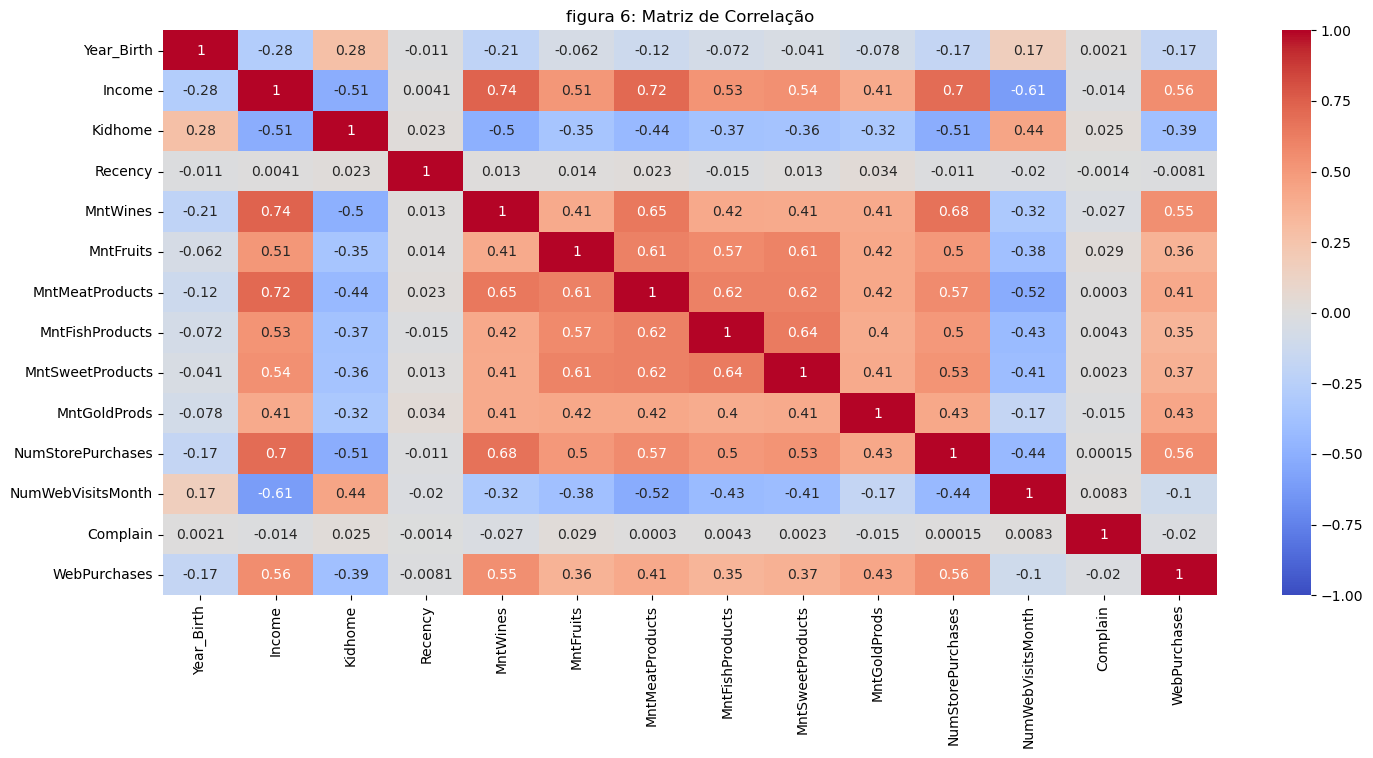

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
Year_Birth,1.000000,-0.280381,0.278855,-0.010853,-0.209591,-0.061728,-0.123915,-0.072082,-0.040615,-0.078386,-0.174308,0.169693,0.002077,-0.173852
Income,-0.280381,1.000000,-0.510303,0.004129,0.737444,0.511335,0.716479,0.531104,0.540958,0.411481,0.697417,-0.607202,-0.013812,0.555620
Kidhome,0.278855,-0.510303,1.000000,0.023299,-0.499152,-0.346726,-0.435674,-0.373414,-0.360775,-0.323077,-0.512438,0.442107,0.024844,-0.387790
Recency,-0.010853,0.004129,0.023299,1.000000,0.013100,0.013784,0.022723,-0.015205,0.013475,0.033900,-0.010510,-0.020332,-0.001372,-0.008096
MntWines,-0.209591,0.737444,-0.499152,0.013100,1.000000,0.408030,0.650617,0.421561,0.410081,0.412662,0.679291,-0.316502,-0.026946,0.551331
MntFruits,-0.061728,0.511335,-0.346726,0.013784,0.408030,1.000000,0.609571,0.573431,0.609162,0.423049,0.504635,-0.383043,0.029390,0.364582
MntMeatProducts,-0.123915,0.716479,-0.435674,0.022723,0.650617,0.609571,1.000000,0.615605,0.615076,0.422477,0.569810,-0.516478,0.000303,0.414320
MntFishProducts,-0.072082,0.531104,-0.373414,-0.015205,0.421561,0.573431,0.615605,1.000000,0.635021,0.399306,0.504764,-0.428997,0.004350,0.346899
MntSweetProducts,-0.040615,0.540958,-0.360775,0.013475,0.410081,0.609162,0.615076,0.635021,1.000000,0.409724,0.525389,-0.406697,0.002311,0.368354
MntGoldProds,-0.078386,0.411481,-0.323077,0.033900,0.412662,0.423049,0.422477,0.399306,0.409724,1.000000,0.427403,-0.174415,-0.015042,0.433946


In [6]:
df_corr=df2[num_cols] .corr()

# df_corr[(df_corr < 0.5)&(df_corr > -0.5)] = pd.NA
# df_corr[df_corr>=0.99] = pd.NA

plt.figure(figsize=(15, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('figura 6: Matriz de Correlação')
plt.tight_layout(rect=[0.0, 0, 1, 0.96])

plt.show()
df_corr

#### Resumo das correlações

* **Income**:* MntWines (0.74),MntMeatProducts (0.72),MntFruits (0.51),MntFishProducts (0.53),MntSweetProducts (0.54),NumStorePurchases (0.70),
WebPurchases (0.56)\
    *Isso indica que a renda está fortemente associada ao nível de consumo e frequência de compras*

* **Kidhome**: tem correlação negativa moderada a forte com renda (-0.51) e gastos (ex.: -0.50 com MntWines, -0.44 com carnes).\
    *Famílias com mais crianças tendem a gastar menos em produtos de luxo (vinho, ouro, doces)*

* **NumWebVisitsMonth** tem correlação negativa com renda (-0.61), gastos e compras.\
    *Clientes que gastam menos visitam mais vezes o site (talvez apenas pesquisem sem comprar)*.

* **Year_Birth** tem correlação negativa com renda (-0.28) e positiva com Kidhome (0.28).\
    *Clientes mais jovens têm mais filhos e menor renda*

* **Recency** (tempo desde última compra) tem correlação muito baixa com praticamente todas as variáveis.\
    *Essa variável captura outro aspecto do comportamento (recenticidade), mas não se relaciona muito com perfil socioeconômico.

* **Complain** é praticamente independente (correlação ≈ 0 com tudo).\
    Importante para análise de satisfação, mas não tem relação direta com consumo.


#### 🚩 Possíveis variáveis redundantes:

Os gastos em produtos (MntWines, MntFruits, MntMeatProducts, MntFishProducts, MntSweetProducts, MntGoldProds) estão muito correlacionados entre si (0.4 a 0.65).


1-Criar uma variável agregada (TotalSpent = soma dos gastos).

2-aplicar PCA para reduzir a dimensionalidade.


NumStorePurchases e WebPurchases também se correlacionam fortemente com renda e gastos.
👉 Podem ser redundantes, mas ainda agregam valor por indicar canal de compra.

Year_Birth pode ser transformado em Idade (2025 - Year_Birth).
👉 Mais interpretável e útil para modelos.

Recency e Complain têm pouco relacionamento com as demais, mas trazem informação única → devem ser mantidas.

### 2.4 Feature Engineering
* Codificação de Variáveis Categóricas
* Separação da Base em X e Y
* Padronização dos Dados
* Redução de Dimensionalidade
* Divisão em Treino e Teste
#### CODIFICAÇÃO DAS VARIAVEIS

In [7]:
# 1. Ordinal Encoding -> Education
# ==========================
education_map = {
    "Basic": 0,
    "2n Cycle": 1,
    "Graduation": 2,
    "Master": 3,
    "PhD": 4
}

df2["Education_cod"] = df2["Education"].map(education_map)

df2 = df2.drop(['Education'], axis=1)
#df2 = df2.drop(['Year_Birth'], axis=1)


df2 = pd.get_dummies(df2, columns=['Marital_Status'], prefix='Marital_Status', drop_first=True,dtype=int)

df2.columns

Index(['Year_Birth', 'Income', 'Kidhome', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain',
       'WebPurchases', 'Education_cod', 'Marital_Status_Married',
       'Marital_Status_Other', 'Marital_Status_Single',
       'Marital_Status_Widow'],
      dtype='object')

In [8]:
# num_cols = df2.select_dtypes(include=['number']).columns

# df_corr=df2[num_cols] .corr()

# df_corr[(df_corr < 0.5)&(df_corr > -0.5)] = pd.NA
# df_corr[df_corr>=0.99] = pd.NA

# plt.figure(figsize=(15, 8))
# sns.heatmap(df_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title('figura 6: Matriz de Correlação')
# plt.tight_layout(rect=[0.0, 0, 1, 0.96])

# plt.show()
# df_corr
df2.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases,Education_cod,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Widow
count,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000,1734.000000
mean,1968.877163,48536.734717,0.502884,48.955594,265.376586,18.504614,122.673587,26.482122,18.550173,34.267013,5.521915,5.566321,0.010957,0.463091,2.483852,0.644175,0.000577,0.217993,0.032872
std,11.561193,19155.938677,0.545392,28.913740,317.137232,28.171037,168.295733,39.288559,27.689119,38.341011,3.138528,2.163789,0.104132,0.498780,1.023962,0.478901,0.024015,0.413002,0.178353
min,1940.000000,7500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,33623.750000,0.000000,24.000000,19.000000,1.000000,14.000000,2.000000,1.000000,7.000000,3.000000,4.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
50%,1970.000000,47412.500000,0.000000,49.000000,128.500000,6.000000,48.000000,10.000000,6.000000,20.000000,4.000000,6.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,1977.000000,63275.250000,1.000000,74.000000,427.500000,23.000000,154.000000,33.000000,23.000000,45.000000,8.000000,7.000000,0.000000,1.000000,3.000000,1.000000,0.000000,0.000000,0.000000
max,1996.000000,101970.000000,2.000000,99.000000,1315.000000,142.000000,792.000000,185.000000,134.000000,178.000000,13.000000,10.000000,1.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000


#### SEPARAÇÃO DAS BASES X E Y, TREINO/TESTE

In [9]:
#SEPARAÇÃO DAS BASES X e Y
X = df2.drop(columns=['WebPurchases'])
y = df2['WebPurchases']

# separacao de base de teste e treino
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)



#### PADRONIZAÇÃO DOS DADOS
Normalização via standarScaler das variavies continuas. 

In [10]:
# padronização apenas das contínuas do treino
cont_features = ["Income","Kidhome","Recency","MntWines","MntFruits",
                 "MntMeatProducts","MntFishProducts","MntSweetProducts",
                 "MntGoldProds","NumStorePurchases","NumWebVisitsMonth",
                 "Year_Birth","Education_cod"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cont_features] = scaler.fit_transform(X_train[cont_features])  # aprende só do treino
X_test_scaled[cont_features] = scaler.transform(X_test[cont_features])        # aplica mesma transformação



#### REDUÇÃO DA DIMENSIONALIDADE

In [11]:
# Teste para avaliar variancia acumulada > 85%
pca_teste=PCA()
pca_teste.fit(X_train_scaled)
explained_variance = pca_teste.explained_variance_ratio_
# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()
# Encontrar número de componentes para 85% de variância
var_acumulada=0.85
n_components = np.argmax(cumulative_variance >= var_acumulada) +1
# Informações adicionais
print(f"\nOs primeiros {n_components} componentes explicam {cumulative_variance[n_components-1]:.2%}")
print(f"Total de componentes disponíveis: {len(explained_variance)}")


Os primeiros 8 componentes explicam 85.32%
Total de componentes disponíveis: 18


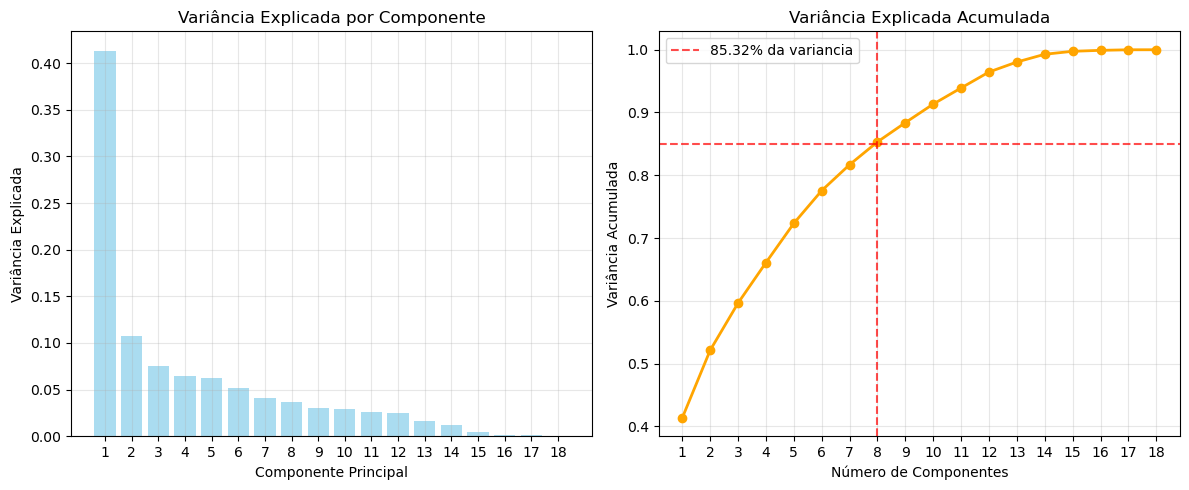

In [12]:
# Criar gráfico mais informativo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
# Gráfico 1: Variância explicada individual
components = range(1, len(explained_variance) + 1)
ax1.bar(components, explained_variance, alpha=0.7, color='skyblue')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Variância Explicada')
ax1.set_title('Variância Explicada por Componente')
ax1.set_xticks(components)
ax1.grid(True, alpha=0.3)

# Gráfico 2: Variância acumulada
ax2.plot(components, cumulative_variance, 'o-', color='orange', linewidth=2)
ax2.axhline(y=var_acumulada, color='red', linestyle='--', alpha=0.7, label=f"{cumulative_variance[n_components-1]:.2%} da variancia")
ax2.axvline(x=n_components, color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Variância Acumulada')
ax2.set_title('Variância Explicada Acumulada')
ax2.set_xticks(components)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Transformar variavel PCA full-->8( na base de treino e test)
pca8 = PCA(n_components= 8 )
pca8.fit(X_train_scaled)
X_train_pca = pca8.transform(X_train_scaled)
X_test_pca = pca8.transform(X_test_scaled)

# ETAPA 3: Modelagem
* RandomFlorest
* Regressão logistica
* Naive bayes
* Decision tree
## 1. RandomFlorest
### Padrão

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score


rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_pca, Y_train)

Y_pred = rf_model.predict(X_test_pca)

print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred))

print("\nRelatório de Classificação:")
print(classification_report(Y_test, Y_pred))
print(f"Acurácia no conjunto de teste: {accuracy_score(Y_test, Y_pred):.4f}")


Matriz de Confusão:
[[231  40]
 [ 28 222]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       271
           1       0.85      0.89      0.87       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521

Acurácia no conjunto de teste: 0.8695


### RandomFlorest Validacao Cruzada - Manual

In [15]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
#============================================================
#VALIDAÇÃO CRUZADA MANUAL (scaler + PCA dentro do fold)
#============================================================

# Definição do modelo
rf_model2 = RandomForestClassifier(random_state=42)

# Configuração do K-Fold
kfold = KFold(n_splits=12, shuffle=True, random_state=42)
scores = []
Y_ts_full = []
Y_pred_full = []

# Validação cruzada manual (sem pipeline) Fazer todo processo manualmente
for train_idx, test_idx in kfold.split(X_train):
    # Divide o conjunto de treino em subpartes (train/ts)
    X_tr, X_ts = X_train.iloc[train_idx], X_train.iloc[test_idx]
    Y_tr, Y_ts = Y_train.iloc[train_idx], Y_train.iloc[test_idx]

    # PADRONIZAÇÃO
    scaler2 = StandardScaler()
    X_tr_scaled = X_tr.copy()
    X_ts_scaled = X_ts.copy()
    X_tr_scaled[cont_features] = scaler2.fit_transform(X_tr[cont_features])
    X_ts_scaled[cont_features] = scaler2.transform(X_ts[cont_features])
    
    # PCA ajustado SOMENTE no treino do fold
    pca8 = PCA(n_components=8)
    X_tr_pca = pca8.fit_transform(X_tr_scaled)
    X_ts_pca = pca8.transform(X_ts_scaled)
    # 
    # Treina o modelo
    rf_model2.fit(X_tr_pca, Y_tr)
    
    # Avalia no fold de validação
    Y_pred = rf_model2.predict(X_ts_pca)
    acc = accuracy_score(Y_ts, Y_pred)
    scores.append(acc)
    
    Y_ts_full.append(Y_ts.to_numpy())
    Y_pred_full.append(Y_pred)

# Concatena todos os folds
Y_ts_full = np.concatenate(Y_ts_full)
Y_pred_full = np.concatenate(Y_pred_full)


# Resultados
scores = np.array(scores)
Y_pred2 = rf_model2.predict(X_test_pca)

print("📋 Relatório de Classificação:")
print(classification_report(Y_test, Y_pred2))
print(f"Acurácia no conjunto de teste: {accuracy_score(Y_test, Y_pred2):.4f}")

📋 Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       271
           1       0.84      0.88      0.86       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521

Acurácia no conjunto de teste: 0.8656


### RandomFlorest pipeline 

In [16]:
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import ColumnTransformer


def print_cv_scores(scores, scoring,title):
    """Imprime resultados do cross_validate de forma organizada"""
    
    print("\n📊" +title)
    print("=" * 65)
    
    # Table header
    header = ["Fold"] + [m.upper() for m in scoring] + ["Fit Time", "Score Time"]
    print(f"{header[0]:<6}", end="")
    for h in header[1:]:
        print(f"{h:<12}", end="")
    print()
    
    # Table rows
    n_folds = len(scores['fit_time'])
    for i in range(n_folds):
        print(f"{i+1:<6}", end="")
        for metric in scoring:
            print(f"{scores[f'test_{metric}'][i]:<12.4f}", end="")
        print(f"{scores['fit_time'][i]:<12.4f}{scores['score_time'][i]:<12.4f}")
    
    # Summary
    print("-" * 65)
    print(f"{'MÉDIA':<6}", end="")
    for metric in scoring:
        mean_val = scores[f'test_{metric}'].mean()
        print(f"{mean_val:<12.4f}", end="")
    print(f"{scores['fit_time'].mean():<12.4f}{scores['score_time'].mean():<12.4f}")
    
    print(f"{'STD':<6}", end="")
    for metric in scoring:
        std_val = scores[f'test_{metric}'].std()
        print(f"{std_val:<12.4f}", end="")
    print(f"{scores['fit_time'].std():<12.4f}{scores['score_time'].std():<12.4f}")


cont_features = ["Income","Kidhome","Recency","MntWines","MntFruits",
                 "MntMeatProducts","MntFishProducts","MntSweetProducts",
                 "MntGoldProds","NumStorePurchases","NumWebVisitsMonth",
                 "Year_Birth","Education_cod"]

scaler_cont = ColumnTransformer(
    transformers=[('scaler', StandardScaler(), cont_features) ],
    remainder='passthrough')  # mantém as outras colunas sem alteração
# Pipeline
pipeline_rf= Pipeline([
    ('scaler_cont', scaler_cont),    # 
    ('pca', PCA(n_components=8)),    # PCA funciona melhor com dados escalados
    ('rf', RandomForestClassifier(random_state=42))
])

pipeline_dt = Pipeline([
    ('scaler_cont', StandardScaler()),    # Opcional para Decision Tree, mas pode ajudar
    ('pca', PCA(n_components=8)),    # Redução de dimensionalidade
    ('dt', DecisionTreeClassifier(random_state=42))
])

pipeline_lr = Pipeline([
    ('scaler_cont', StandardScaler()),    # ESSENCIAL para Regressão Logística
    ('pca', PCA(n_components=8)),    # Redução de dimensionalidade
    ('lr', LogisticRegression(random_state=42))
])

# Pipeline para Naive Bayes
pipeline_nb = Pipeline([
    ('scaler_cont', StandardScaler()),    # Importante para Naive Bayes
    ('pca', PCA(n_components=8)),    # Redução de dimensionalidade
    ('nb', GaussianNB())             # Naive Bayes Gaussiano
])

pipeline_dt_tuned = Pipeline([
    ('scaler_cont', StandardScaler()),
    ('pca', PCA(n_components=8)),
    ('dt', DecisionTreeClassifier(
        random_state=42,
        max_depth=10,           # Controla overfitting
        min_samples_split=20,   # Controla overfitting  
        min_samples_leaf=10    # Controla overfitting
    ))
])

pipeline_lr_tuned = Pipeline([
    ('scaler_cont', StandardScaler()),
    ('pca', PCA(n_components=8)),
    ('lr', LogisticRegression(
        random_state=42,
        C=1.1,                  # Força de regularização
        solver='lbfgs',         # Algoritmo de otimização
        max_iter=1000         # Número máximo de iterações
    ))
])
# KFold
cross_validation = KFold(n_splits=12, shuffle=True, random_state=42)

# Métricas
scoring = ['accuracy', 'precision', 'recall', 'f1']


# Cross-validate
scores_rf = cross_validate(pipeline_rf, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)
scores_dt = cross_validate(pipeline_dt, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)
scores_dt_tuned = cross_validate(pipeline_dt_tuned, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)

scores_lr = cross_validate(pipeline_lr, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)
scores_lr_tuned = cross_validate(pipeline_lr_tuned, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)

scores_nb = cross_validate(pipeline_nb, X_train, Y_train, cv=cross_validation, scoring=scoring, return_train_score=False)


# Função que você já tem
print_cv_scores(scores_rf, scoring, "🌲🌳Random Forest com PCA - KFold")
print_cv_scores(scores_dt, scoring, "🌲Decision Tree com PCA - KFold")
print_cv_scores(scores_dt_tuned, scoring, "🌲Decision Tree com PCA - KFold")
print_cv_scores(scores_lr, scoring, "Regressão Logistica com PCA - KFold")
print_cv_scores(scores_lr_tuned, scoring, "Regressão Logistica com PCA - KFold")
print_cv_scores(scores_nb, scoring, "Naive Bayes com PCA - KFold")




📊🌲🌳Random Forest com PCA - KFold
Fold  ACCURACY    PRECISION   RECALL      F1          Fit Time    Score Time  
1     0.8725      0.8679      0.8846      0.8762      0.3155      0.0211      
2     0.8614      0.8727      0.8727      0.8727      0.3024      0.0210      
3     0.8317      0.7872      0.8409      0.8132      0.3058      0.0213      
4     0.9010      0.8222      0.9487      0.8810      0.3016      0.0213      
5     0.8713      0.8367      0.8913      0.8632      0.3007      0.0213      
6     0.8020      0.7600      0.8261      0.7917      0.3059      0.0207      
7     0.8020      0.7917      0.7917      0.7917      0.3102      0.0210      
8     0.9406      0.9200      0.9583      0.9388      0.3070      0.0209      
9     0.9307      0.8627      1.0000      0.9263      0.3185      0.0208      
10    0.8812      0.7600      1.0000      0.8636      0.2952      0.0206      
11    0.8515      0.7826      0.8780      0.8276      0.3048      0.0207      
12    0.9010      

In [17]:

# 1️⃣ Treina o modelo final (com os mesmos passos do pipeline)
pipeline_rf.fit(X_train, Y_train)
pipeline_dt.fit(X_train, Y_train)
pipeline_lr.fit(X_train, Y_train)

# 2️⃣ Faz previsões no conjunto de teste
Y_pred_rf = pipeline_rf.predict(X_test)
Y_pred_dt = pipeline_dt.predict(X_test)
Y_pred_lr = pipeline_lr.predict(X_test)

# 3️⃣ Exibe o relatório de classificação
print("📋 Relatório de Classificação (dados de teste): Random Florest")
print(classification_report(Y_test, Y_pred_rf))
print(f"\nAcurácia no conjunto de teste: {accuracy_score(Y_test, Y_pred_rf):.4f}")
print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred_rf))

print("📋 Relatório de Classificação (dados de teste): Random Florest")
print(classification_report(Y_test, Y_pred_dt))
print(f"\nAcurácia no conjunto de teste: {accuracy_score(Y_test, Y_pred_dt):.4f}")
print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred_dt))

print("📋 Relatório de Classificação (dados de teste): Random Florest")
print(classification_report(Y_test, Y_pred_lr))
print(f"\nAcurácia no conjunto de teste: {accuracy_score(Y_test, Y_pred_lr):.4f}")
print("Matriz de Confusão:")
print(confusion_matrix(Y_test, Y_pred_lr))


📋 Relatório de Classificação (dados de teste): Random Florest
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       271
           1       0.85      0.89      0.87       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521


Acurácia no conjunto de teste: 0.8695
Matriz de Confusão:
[[231  40]
 [ 28 222]]
📋 Relatório de Classificação (dados de teste): Random Florest
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       271
           1       0.85      0.80      0.82       250

    accuracy                           0.83       521
   macro avg       0.83      0.83      0.83       521
weighted avg       0.83      0.83      0.83       521


Acurácia no conjunto de teste: 0.8330
Matriz de Confusão:
[[235  36]
 [ 51 199]]
📋 Relatório de Classificação (dados de teste): Random Flor

In [18]:
def resultados_pipelines(pipeline_name, X_train, Y_train, X_test, Y_test, model_name=None):
    print(f"\n{'='*70}")
    print(f"🎯 {model_name.upper()}")
    print(f"{'='*70}")
    
    # Treina o modelo
    pipeline_name.fit(X_train, Y_train)
        
    # Faz previsões
    Y_pred = pipeline_name.predict(X_test)
    Y_pred_proba = pipeline_name.predict_proba(X_test)[:, 1] if hasattr(pipeline_name, 'predict_proba') else None
        
    # Calcula métricas
    accuracy = accuracy_score(Y_test, Y_pred)
    cm = confusion_matrix(Y_test, Y_pred)
    report = classification_report(Y_test, Y_pred, output_dict=True)
        
    # Armazena resultados
    results = {}  # Adicionado para armazenar os resultados
    results[model_name] = {
        'pipeline': pipeline_name,  # Corrigido de 'pipeline' para 'pipeline_name'
        'predictions': Y_pred,
        'probabilities': Y_pred_proba,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'classification_report': report
    }
        
    # Exibe resultados formatados
    print(f"📊 **Acurácia no Teste**: {accuracy:.4f}")
        
    print(f"\n📋 **Relatório de Classificação**:")
    print(classification_report(Y_test, Y_pred))
    print(f"🎯 **Matriz de Confusão**:")
    print(f"               Previsto 0   Previsto 1")
    print(f"Real 0         {cm[0,0]:<11} {cm[0,1]:<11}")
    print(f"Real 1         {cm[1,0]:<11} {cm[1,1]:<11}")
    print(f"{'─'*70}")
    
    return results # Adicionado retorno dos resultados
    

# Chamada da função corrigida
out=resultados_pipelines(pipeline_rf, X_train, Y_train, X_test, Y_test, model_name='RANDOM Florest')
outdt=resultados_pipelines(pipeline_dt, X_train, Y_train, X_test, Y_test, model_name='Decision Tree')
outdt2=resultados_pipelines(pipeline_dt_tuned, X_train, Y_train, X_test, Y_test, model_name='Decision Tree+')
outlr=resultados_pipelines(pipeline_lr, X_train, Y_train, X_test, Y_test, model_name='Regressão Logistica')
outlr2=resultados_pipelines(pipeline_lr_tuned, X_train, Y_train, X_test, Y_test, model_name='Regressão Logistica++')
outnb=resultados_pipelines(pipeline_nb, X_train, Y_train, X_test, Y_test, model_name='Naive Bayes')



🎯 RANDOM FLOREST
📊 **Acurácia no Teste**: 0.8695

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       271
           1       0.85      0.89      0.87       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         231         40         
Real 1         28          222        
──────────────────────────────────────────────────────────────────────

🎯 DECISION TREE
📊 **Acurácia no Teste**: 0.8330

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       271
           1       0.85      0.80      0.82       250

    accuracy                           0.83       521
   macro avg       0.83      0.83      0.83       521
weighted avg      

In [19]:
# ===========================================================
# ✅ RESUMO DOS RESULTADOS 
# ===========================================================
def resumo_cv(nome, scores):
    """Retorna um dicionário com as métricas médias do cross_validate"""
    return {
        'Modelo': nome,
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision']),
        'Recall': np.mean(scores['test_recall']),
        'F1-score': np.mean(scores['test_f1'])
    }

# ✅ Consolida resultados em um DataFrame
resumo = pd.DataFrame([
    resumo_cv('Random Forest', scores_rf),
    resumo_cv('Decision Tree', scores_dt),
    resumo_cv('Decision Tree Tuned', scores_dt_tuned),
    resumo_cv('Logistic Regression', scores_lr),
    resumo_cv('Logistic Regression Tuned', scores_lr_tuned),
    resumo_cv('Naive Bayes', scores_nb)

])

# ✅ Exibe a tabela com resultados comparativos
print("\n📋 **Resumo dos Modelos (Médias das Métricas de Cross-Validation)**")
print("="*70)
print(resumo.round(4))
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


📋 **Resumo dos Modelos (Médias das Métricas de Cross-Validation)**
                      Modelo  Accuracy  Precision  Recall  F1-score
0              Random Forest    0.8706     0.8294  0.9013    0.8626
1              Decision Tree    0.7914     0.7761  0.7612    0.7666
2        Decision Tree Tuned    0.8293     0.8020  0.8244    0.8113
3        Logistic Regression    0.8310     0.8419  0.7769    0.8052
4  Logistic Regression Tuned    0.8293     0.8414  0.7735    0.8030
5                Naive Bayes    0.7559     0.7924  0.6284    0.6988


 ## Extra - BestParameters para Random Florest

In [20]:
#extra
#from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Parâmetros mais amplos mas com menos combinações
param_distributions = {
    'rf__n_estimators': [50, 100, 200, 300, 400],
    'rf__max_depth': [5, 10, 15, 20, 25, 30, None],
    'rf__min_samples_split': [2, 5, 10, 15],
    'rf__min_samples_leaf': [1, 2, 4, 6],
    'rf__max_features': ['sqrt', 'log2', 0.5, 0.7],
    'rf__bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_distributions,
    n_iter=30,              # Testa apenas 30 combinações aleatórias
    cv=12,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, Y_train)


# 4. MOSTRAR RESULTADOS
print(f"\n🎯 MELHORES PARÂMETROS ENCONTRADOS:")
print(random_search.best_params_)
print(f"📊 Melhor score na validação cruzada: {random_search.best_score_:.4f}")

# 5. AVALIAR O MELHOR MODELO NO TESTE
best_rf_model = random_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

print(f"\n📈 DESEMPENHO NO CONJUNTO DE TESTE:")
print(f"Acurácia: {accuracy_score(Y_test, y_pred_tuned):.4f}")
print("\n📋 Relatório de Classificação (Modelo Tuneado):")
print(classification_report(Y_test, y_pred_tuned))

# 6. COMPARAR COM O MODELO ORIGINAL
print(f"\n🆚 COMPARAÇÃO COM MODELO ORIGINAL:")
y_pred_original = pipeline_rf.fit(X_train, Y_train).predict(X_test)
print(f"Acurácia original: {accuracy_score(Y_test, y_pred_original):.4f}")
print(f"Acurácia tuneada:  {accuracy_score(Y_test, y_pred_tuned):.4f}")
print(f"Melhoria: {(accuracy_score(Y_test, y_pred_tuned)/accuracy_score(Y_test, y_pred_original)-1)*100:.2f}%")
cm_o = confusion_matrix(Y_test, y_pred_original)
cm_t = confusion_matrix(Y_test, y_pred_tuned)


print(f"🎯 **Matriz de Confusão Original**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm_o[0,0]:<11} {cm_o[0,1]:<11}")
print(f"Real 1         {cm_o[1,0]:<11} {cm_o[1,1]:<11}")
print(f"{'─'*70}")

print(f"🎯 **Matriz de Confusão tunnig**:")
print(f"               Previsto 0   Previsto 1")
print(f"Real 0         {cm_t[0,0]:<11} {cm_t[0,1]:<11}")
print(f"Real 1         {cm_t[1,0]:<11} {cm_t[1,1]:<11}")
print(f"{'─'*70}")

Fitting 12 folds for each of 30 candidates, totalling 360 fits

🎯 MELHORES PARÂMETROS ENCONTRADOS:
{'rf__n_estimators': 50, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 30, 'rf__bootstrap': True}
📊 Melhor score na validação cruzada: 0.8747

📈 DESEMPENHO NO CONJUNTO DE TESTE:
Acurácia: 0.8791

📋 Relatório de Classificação (Modelo Tuneado):
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       271
           1       0.86      0.90      0.88       250

    accuracy                           0.88       521
   macro avg       0.88      0.88      0.88       521
weighted avg       0.88      0.88      0.88       521


🆚 COMPARAÇÃO COM MODELO ORIGINAL:
Acurácia original: 0.8695
Acurácia tuneada:  0.8791
Melhoria: 1.10%
🎯 **Matriz de Confusão Original**:
               Previsto 0   Previsto 1
Real 0         231         40         
Real 1         28          222        
──────────────────────

 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       271
           1       0.84      0.89      0.86       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521


🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         228         43         
<!-- Real 1         27          223  -->

In [30]:
A=random_search.best_params_
type(A)
A

{'rf__n_estimators': 50,
 'rf__min_samples_split': 5,
 'rf__min_samples_leaf': 1,
 'rf__max_features': 'log2',
 'rf__max_depth': 30,
 'rf__bootstrap': True}

In [22]:
print("Parâmetros do RandomForest após atualização:")

# Aplicar os melhores parâmetros na pipeline
print(pipeline_rf.named_steps['rf'].get_params())

Parâmetros do RandomForest após atualização:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


Parâmetros do RandomForest após atualização:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 30, 'max_features': 'log2', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 50, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [36]:
out=resultados_pipelines(pipeline_rf, X_train, Y_train, X_test, Y_test, model_name='RANDOM Florest')
out=resultados_pipelines(pipeline_rf2, X_train, Y_train, X_test, Y_test, model_name='RANDOM Florest2')


🎯 RANDOM FLOREST
📊 **Acurácia no Teste**: 0.8695

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.89      0.85      0.87       271
           1       0.85      0.89      0.87       250

    accuracy                           0.87       521
   macro avg       0.87      0.87      0.87       521
weighted avg       0.87      0.87      0.87       521

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         231         40         
Real 1         28          222        
──────────────────────────────────────────────────────────────────────

🎯 RANDOM FLOREST2
📊 **Acurácia no Teste**: 0.8791

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       271
           1       0.86      0.90      0.88       250

    accuracy                           0.88       521
   macro avg       0.88      0.88      0.88       521
weighted avg    

In [38]:
from sklearn.base import clone

pipeline_rf2 = clone(pipeline_rf)
pipeline_rf2.set_params(**random_search.best_params_)
out=resultados_pipelines(pipeline_rf2, X_train, Y_train, X_test, Y_test, model_name='RANDOM Florest2')


🎯 RANDOM FLOREST2
📊 **Acurácia no Teste**: 0.8791

📋 **Relatório de Classificação**:
              precision    recall  f1-score   support

           0       0.90      0.86      0.88       271
           1       0.86      0.90      0.88       250

    accuracy                           0.88       521
   macro avg       0.88      0.88      0.88       521
weighted avg       0.88      0.88      0.88       521

🎯 **Matriz de Confusão**:
               Previsto 0   Previsto 1
Real 0         234         37         
Real 1         26          224        
──────────────────────────────────────────────────────────────────────
